# Sentiment-Based Trading Strategy Backtesting

This notebook analyzes the relationship between news sentiment scores and stock returns for AAPL and TSLA. We'll extract sentiment data, download stock prices, calculate returns, and visualize the correlation between sentiment and performance.

## Objectives:
1. Extract sentiment scores for AAPL and TSLA from processed data
2. Download historical stock data using yfinance
3. Calculate daily returns and compare with sentiment scores
4. Create scatter plots to visualize sentiment-return relationships
5. Analyze correlation patterns for trading strategy development


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
from scipy import stats
import pickle

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Suppress warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")


Libraries imported successfully!
Pandas version: 2.3.2
NumPy version: 2.3.3
Matplotlib version: 3.10.6
Seaborn version: 0.13.2


In [6]:
# Load the daily ticker sentiment data
print("Loading daily ticker sentiment data...")

# Load the processed data from notebook 03
daily_sentiment_df = pd.read_csv('../data/processed/daily_ticker_sentiment.csv')

# Convert date column to datetime
daily_sentiment_df['date'] = pd.to_datetime(daily_sentiment_df['date'])

print(f"Data loaded successfully!")
print(f"Shape: {daily_sentiment_df.shape}")
print(f"Date range: {daily_sentiment_df['date'].min()} to {daily_sentiment_df['date'].max()}")
print(f"Unique tickers: {daily_sentiment_df['ticker'].nunique()}")

# Display sample data
print(f"\nSample data:")
print(daily_sentiment_df.head())

# Check if APPLE and TESLA are in the data (note: tickers are stored as APPLE/TESLA, not AAPL/TSLA)
print(f"\nChecking for APPLE and TESLA in the data:")
aapl_data = daily_sentiment_df[daily_sentiment_df['ticker'] == 'APPLE']
tsla_data = daily_sentiment_df[daily_sentiment_df['ticker'] == 'TESLA']

print(f"APPLE records: {len(aapl_data)}")
print(f"TESLA records: {len(tsla_data)}")

if len(aapl_data) > 0:
    print(f"APPLE date range: {aapl_data['date'].min()} to {aapl_data['date'].max()}")
if len(tsla_data) > 0:
    print(f"TESLA date range: {tsla_data['date'].min()} to {tsla_data['date'].max()}")


Loading daily ticker sentiment data...
Data loaded successfully!
Shape: (168027, 12)
Date range: 2017-12-17 00:00:00 to 2020-07-18 00:00:00
Unique tickers: 6043

Sample data:
  ticker  avg_sentiment_score  sentiment_std  mention_count  \
0      A               0.0659         0.5311              8   
1      A              -0.3522         0.4823              5   
2      A               0.0000         0.0000              3   
3      A               0.0000            NaN              1   
4      A              -0.4504         0.3328              4   

   min_sentiment_score  max_sentiment_score  avg_confidence  \
0              -0.9431               0.8756          0.7570   
1              -0.8927               0.0000          0.8644   
2               0.0000               0.0000          0.8508   
3               0.0000               0.0000          0.6055   
4              -0.8033               0.0000          0.6846   

   avg_positive_score  avg_negative_score  avg_neutral_score  \
0  

In [7]:
# Extract sentiment data for APPLE and TESLA (note: using APPLE/TESLA as stored in dataset)
print("Extracting sentiment data for APPLE and TESLA...")

# Filter data for our target tickers
target_tickers = ['APPLE', 'TESLA']
sentiment_data = daily_sentiment_df[daily_sentiment_df['ticker'].isin(target_tickers)].copy()

print(f"Total records for APPLE and TESLA: {len(sentiment_data)}")

# Separate data for each ticker
aapl_sentiment = sentiment_data[sentiment_data['ticker'] == 'APPLE'].copy()
tsla_sentiment = sentiment_data[sentiment_data['ticker'] == 'TESLA'].copy()

print(f"\nAPPLE sentiment data:")
print(f"  Records: {len(aapl_sentiment)}")
if len(aapl_sentiment) > 0:
    print(f"  Date range: {aapl_sentiment['date'].min()} to {aapl_sentiment['date'].max()}")
    print(f"  Avg sentiment score: {aapl_sentiment['avg_sentiment_score'].mean():.3f}")
    print(f"  Sentiment std: {aapl_sentiment['avg_sentiment_score'].std():.3f}")
    print(f"  Total mentions: {aapl_sentiment['mention_count'].sum()}")

print(f"\nTESLA sentiment data:")
print(f"  Records: {len(tsla_sentiment)}")
if len(tsla_sentiment) > 0:
    print(f"  Date range: {tsla_sentiment['date'].min()} to {tsla_sentiment['date'].max()}")
    print(f"  Avg sentiment score: {tsla_sentiment['avg_sentiment_score'].mean():.3f}")
    print(f"  Sentiment std: {tsla_sentiment['avg_sentiment_score'].std():.3f}")
    print(f"  Total mentions: {tsla_sentiment['mention_count'].sum()}")

# Display sample data for each ticker
if len(aapl_sentiment) > 0:
    print(f"\nSample APPLE sentiment data:")
    print(aapl_sentiment[['date', 'avg_sentiment_score', 'mention_count', 'dominant_sentiment']].head())

if len(tsla_sentiment) > 0:
    print(f"\nSample TESLA sentiment data:")
    print(tsla_sentiment[['date', 'avg_sentiment_score', 'mention_count', 'dominant_sentiment']].head())


Extracting sentiment data for APPLE and TESLA...
Total records for APPLE and TESLA: 777

APPLE sentiment data:
  Records: 370
  Date range: 2017-12-28 00:00:00 to 2020-07-16 00:00:00
  Avg sentiment score: -0.135
  Sentiment std: 0.511
  Total mentions: 673

TESLA sentiment data:
  Records: 407
  Date range: 2017-12-31 00:00:00 to 2020-07-18 00:00:00
  Avg sentiment score: -0.143
  Sentiment std: 0.516
  Total mentions: 757

Sample APPLE sentiment data:
           date  avg_sentiment_score  mention_count dominant_sentiment
4601 2017-12-28               0.0000              1            neutral
4602 2018-01-02              -0.2962              2           negative
4603 2018-01-03               0.6849              1           positive
4604 2018-01-17               0.0000              1            neutral
4605 2018-01-18               0.7797              1           positive

Sample TESLA sentiment data:
             date  avg_sentiment_score  mention_count dominant_sentiment
141419 2017-1

In [8]:
# Download stock data using yfinance
print("Downloading stock data for AAPL and TSLA...")

# Define the date range based on our sentiment data
if len(sentiment_data) > 0:
    start_date = sentiment_data['date'].min().strftime('%Y-%m-%d')
    end_date = sentiment_data['date'].max().strftime('%Y-%m-%d')
else:
    # Fallback date range
    start_date = '2017-12-17'
    end_date = '2020-07-18'

print(f"Date range: {start_date} to {end_date}")

# Download data for both stocks
try:
    aapl_stock = yf.download('AAPL', start=start_date, end=end_date, progress=False)
    tsla_stock = yf.download('TSLA', start=start_date, end=end_date, progress=False)
    
    print(f"AAPL stock data downloaded: {len(aapl_stock)} records")
    print(f"TSLA stock data downloaded: {len(tsla_stock)} records")
    
    # Display sample data
    print(f"\nSample AAPL stock data:")
    print(aapl_stock.head())
    
    print(f"\nSample TSLA stock data:")
    print(tsla_stock.head())
    
except Exception as e:
    print(f"Error downloading stock data: {e}")
    print("Please check your internet connection and try again.")


Date range: 2017-12-28 to 2020-07-18


AAPL stock data downloaded: 642 records
TSLA stock data downloaded: 642 records

Sample AAPL stock data:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2017-12-28  40.104389  40.284893  39.963736  40.085635   65920800
2017-12-29  39.670708  39.989518  39.668365  39.973110  103999600
2018-01-02  40.380985  40.390364  39.677729  39.888708  102223600
2018-01-03  40.373951  40.917804  40.310660  40.444277  118071600
2018-01-04  40.561485  40.664630  40.338788  40.446619   89738400

Sample TSLA stock data:
Price           Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2017-12-28  21.024000  21.054667  20.636000  20.783333   64744500
2017-12-29  20.756666  21.094000  20.666668  21.078667   56658000
2018-01-02  

In [ ]:
# Calculate daily returns
print("Calculating daily returns for AAPL and TSLA...")

# Debug: Check the structure of the downloaded data
print(f"AAPL data structure:")
print(f"  Columns: {aapl_stock.columns}")
print(f"  Column types: {type(aapl_stock.columns)}")
print(f"  Shape: {aapl_stock.shape}")

print(f"\nTSLA data structure:")
print(f"  Columns: {tsla_stock.columns}")
print(f"  Column types: {type(tsla_stock.columns)}")
print(f"  Shape: {tsla_stock.shape}")

# Function to calculate daily returns
def calculate_returns(stock_data, ticker_name):
    """Calculate daily returns from stock price data"""
    try:
        # Handle different yfinance data structures
        if isinstance(stock_data.columns, pd.MultiIndex):
            # MultiIndex columns (when downloading multiple tickers)
            print(f"  MultiIndex columns detected for {ticker_name}")
            close_prices = stock_data[('Close', ticker_name)]
        else:
            # Single ticker columns
            print(f"  Single column structure for {ticker_name}")
            close_prices = stock_data['Close']
        
        returns = close_prices.pct_change() * 100  # Convert to percentage
        return returns
    except Exception as e:
        print(f"Error calculating returns for {ticker_name}: {e}")
        # Try alternative approach
        if 'Close' in stock_data.columns:
            close_prices = stock_data['Close']
        else:
            # If Close column doesn't exist, try to find it
            close_cols = [col for col in stock_data.columns if 'Close' in str(col)]
            if close_cols:
                close_prices = stock_data[close_cols[0]]
            else:
                raise ValueError(f"Could not find Close price column for {ticker_name}")
        
        returns = close_prices.pct_change() * 100
        return returns

# Calculate returns for both stocks
aapl_returns = calculate_returns(aapl_stock, 'AAPL')
tsla_returns = calculate_returns(tsla_stock, 'TSLA')

# Create DataFrames with date and returns
aapl_returns_df = pd.DataFrame({
    'date': aapl_stock.index,
    'returns': aapl_returns
}).reset_index(drop=True)

tsla_returns_df = pd.DataFrame({
    'date': tsla_stock.index,
    'returns': tsla_returns
}).reset_index(drop=True)

# Convert date columns to datetime for merging
aapl_returns_df['date'] = pd.to_datetime(aapl_returns_df['date'])
tsla_returns_df['date'] = pd.to_datetime(tsla_returns_df['date'])

print(f"AAPL returns calculated: {len(aapl_returns_df)} records")
print(f"TSLA returns calculated: {len(tsla_returns_df)} records")

# Check for any issues with the returns calculation
print(f"\nChecking returns data:")
print(f"AAPL returns - NaN values: {aapl_returns_df['returns'].isna().sum()}")
print(f"TSLA returns - NaN values: {tsla_returns_df['returns'].isna().sum()}")

# Display sample returns data
print(f"\nSample AAPL returns:")
print(aapl_returns_df.head())

print(f"\nSample TSLA returns:")
print(tsla_returns_df.head())

# Basic statistics
print(f"\nAAPL returns statistics:")
print(f"  Mean: {aapl_returns_df['returns'].mean():.3f}%")
print(f"  Std: {aapl_returns_df['returns'].std():.3f}%")
print(f"  Min: {aapl_returns_df['returns'].min():.3f}%")
print(f"  Max: {aapl_returns_df['returns'].max():.3f}%")

print(f"\nTSLA returns statistics:")
print(f"  Mean: {tsla_returns_df['returns'].mean():.3f}%")
print(f"  Std: {tsla_returns_df['returns'].std():.3f}%")
print(f"  Min: {tsla_returns_df['returns'].min():.3f}%")
print(f"  Max: {tsla_returns_df['returns'].max():.3f}%")


Calculating daily returns for AAPL and TSLA...
AAPL returns calculated: 642 records
TSLA returns calculated: 642 records

Sample AAPL returns:
        date   returns
0 2017-12-28       NaN
1 2017-12-29 -1.081382
2 2018-01-02  1.790433
3 2018-01-03 -0.017420
4 2018-01-04  0.464493

Sample TSLA returns:
        date   returns
0 2017-12-28       NaN
1 2017-12-29 -1.271566
2 2018-01-02  2.948457
3 2018-01-03 -1.023311
4 2018-01-04 -0.828998

AAPL returns statistics:
  Mean: 0.155%
  Std: 2.132%
  Min: -12.865%
  Max: 11.981%

TSLA returns statistics:
  Mean: 0.329%
  Std: 4.154%
  Min: -18.578%
  Max: 19.895%


In [11]:
# Merge sentiment and returns data
print("Merging sentiment and returns data...")

# Merge AAPL data
aapl_merged = pd.merge(aapl_sentiment, aapl_returns_df, on='date', how='inner')
print(f"AAPL merged data: {len(aapl_merged)} records")

# Merge TSLA data
tsla_merged = pd.merge(tsla_sentiment, tsla_returns_df, on='date', how='inner')
print(f"TSLA merged data: {len(tsla_merged)} records")

# Display sample merged data
if len(aapl_merged) > 0:
    print(f"\nSample AAPL merged data:")
    print(aapl_merged[['date', 'avg_sentiment_score', 'returns', 'mention_count']].head())

if len(tsla_merged) > 0:
    print(f"\nSample TSLA merged data:")
    print(tsla_merged[['date', 'avg_sentiment_score', 'returns', 'mention_count']].head())

# Check for any missing data
print(f"\nData quality check:")
print(f"AAPL - Missing sentiment scores: {aapl_merged['avg_sentiment_score'].isna().sum()}")
print(f"AAPL - Missing returns: {aapl_merged['returns'].isna().sum()}")
print(f"TSLA - Missing sentiment scores: {tsla_merged['avg_sentiment_score'].isna().sum()}")
print(f"TSLA - Missing returns: {tsla_merged['returns'].isna().sum()}")

# Remove any rows with missing data
aapl_clean = aapl_merged.dropna(subset=['avg_sentiment_score', 'returns'])
tsla_clean = tsla_merged.dropna(subset=['avg_sentiment_score', 'returns'])

print(f"\nClean data:")
print(f"AAPL clean records: {len(aapl_clean)}")
print(f"TSLA clean records: {len(tsla_clean)}")


Merging sentiment and returns data...
AAPL merged data: 341 records
TSLA merged data: 361 records

Sample AAPL merged data:
        date  avg_sentiment_score   returns  mention_count
0 2017-12-28               0.0000       NaN              1
1 2018-01-02              -0.2962  1.790433              2
2 2018-01-03               0.6849 -0.017420              1
3 2018-01-17               0.0000  1.651599              1
4 2018-01-18               0.7797  0.089352              1

Sample TSLA merged data:
        date  avg_sentiment_score   returns  mention_count
0 2018-01-08               0.0000  6.263822              1
1 2018-01-26               0.6396  1.543066              1
2 2018-02-08              -0.9541 -8.628986              1
3 2018-03-20               0.0000 -0.959943              1
4 2018-03-22               0.0000 -2.347326              1

Data quality check:
AAPL - Missing sentiment scores: 0
AAPL - Missing returns: 1
TSLA - Missing sentiment scores: 0
TSLA - Missing returns: 0

Creating scatter plots for sentiment vs returns...


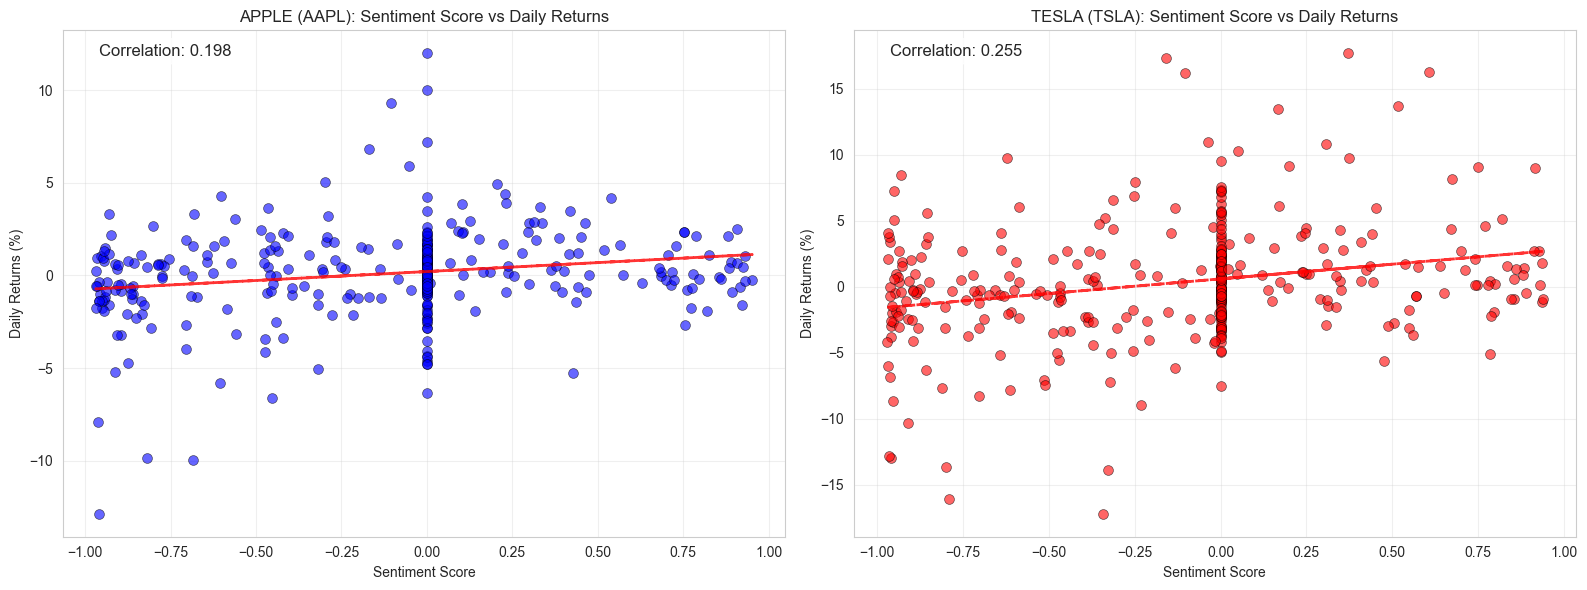


=== SCATTER PLOT SUMMARY ===
APPLE (AAPL):
  Data points: 340
  Correlation coefficient: 0.198
  Sentiment range: -0.969 to 0.952
  Returns range: -12.865% to 11.981%

TESLA (TSLA):
  Data points: 361
  Correlation coefficient: 0.255
  Sentiment range: -0.973 to 0.940
  Returns range: -17.176% to 17.669%


In [12]:
# Create scatter plots: Sentiment vs Returns
print("Creating scatter plots for sentiment vs returns...")

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AAPL scatter plot
if len(aapl_clean) > 0:
    axes[0].scatter(aapl_clean['avg_sentiment_score'], aapl_clean['returns'], 
                   alpha=0.6, s=50, color='blue', edgecolors='black', linewidth=0.5)
    axes[0].set_xlabel('Sentiment Score')
    axes[0].set_ylabel('Daily Returns (%)')
    axes[0].set_title('APPLE (AAPL): Sentiment Score vs Daily Returns')
    axes[0].grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(aapl_clean['avg_sentiment_score'], aapl_clean['returns'], 1)
    p = np.poly1d(z)
    axes[0].plot(aapl_clean['avg_sentiment_score'], p(aapl_clean['avg_sentiment_score']), 
                "r--", alpha=0.8, linewidth=2)
    
    # Add correlation coefficient
    corr_coef = np.corrcoef(aapl_clean['avg_sentiment_score'], aapl_clean['returns'])[0, 1]
    axes[0].text(0.05, 0.95, f'Correlation: {corr_coef:.3f}', 
                transform=axes[0].transAxes, fontsize=12, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
else:
    axes[0].text(0.5, 0.5, 'No APPLE data available', ha='center', va='center', 
                transform=axes[0].transAxes, fontsize=14)
    axes[0].set_title('APPLE (AAPL): No Data Available')

# TSLA scatter plot
if len(tsla_clean) > 0:
    axes[1].scatter(tsla_clean['avg_sentiment_score'], tsla_clean['returns'], 
                   alpha=0.6, s=50, color='red', edgecolors='black', linewidth=0.5)
    axes[1].set_xlabel('Sentiment Score')
    axes[1].set_ylabel('Daily Returns (%)')
    axes[1].set_title('TESLA (TSLA): Sentiment Score vs Daily Returns')
    axes[1].grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(tsla_clean['avg_sentiment_score'], tsla_clean['returns'], 1)
    p = np.poly1d(z)
    axes[1].plot(tsla_clean['avg_sentiment_score'], p(tsla_clean['avg_sentiment_score']), 
                "r--", alpha=0.8, linewidth=2)
    
    # Add correlation coefficient
    corr_coef = np.corrcoef(tsla_clean['avg_sentiment_score'], tsla_clean['returns'])[0, 1]
    axes[1].text(0.05, 0.95, f'Correlation: {corr_coef:.3f}', 
                transform=axes[1].transAxes, fontsize=12, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
else:
    axes[1].text(0.5, 0.5, 'No TESLA data available', ha='center', va='center', 
                transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('TESLA (TSLA): No Data Available')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== SCATTER PLOT SUMMARY ===")
if len(aapl_clean) > 0:
    aapl_corr = np.corrcoef(aapl_clean['avg_sentiment_score'], aapl_clean['returns'])[0, 1]
    print(f"APPLE (AAPL):")
    print(f"  Data points: {len(aapl_clean)}")
    print(f"  Correlation coefficient: {aapl_corr:.3f}")
    print(f"  Sentiment range: {aapl_clean['avg_sentiment_score'].min():.3f} to {aapl_clean['avg_sentiment_score'].max():.3f}")
    print(f"  Returns range: {aapl_clean['returns'].min():.3f}% to {aapl_clean['returns'].max():.3f}%")

if len(tsla_clean) > 0:
    tsla_corr = np.corrcoef(tsla_clean['avg_sentiment_score'], tsla_clean['returns'])[0, 1]
    print(f"\nTESLA (TSLA):")
    print(f"  Data points: {len(tsla_clean)}")
    print(f"  Correlation coefficient: {tsla_corr:.3f}")
    print(f"  Sentiment range: {tsla_clean['avg_sentiment_score'].min():.3f} to {tsla_clean['avg_sentiment_score'].max():.3f}")
    print(f"  Returns range: {tsla_clean['returns'].min():.3f}% to {tsla_clean['returns'].max():.3f}%")


Performing advanced correlation analysis...


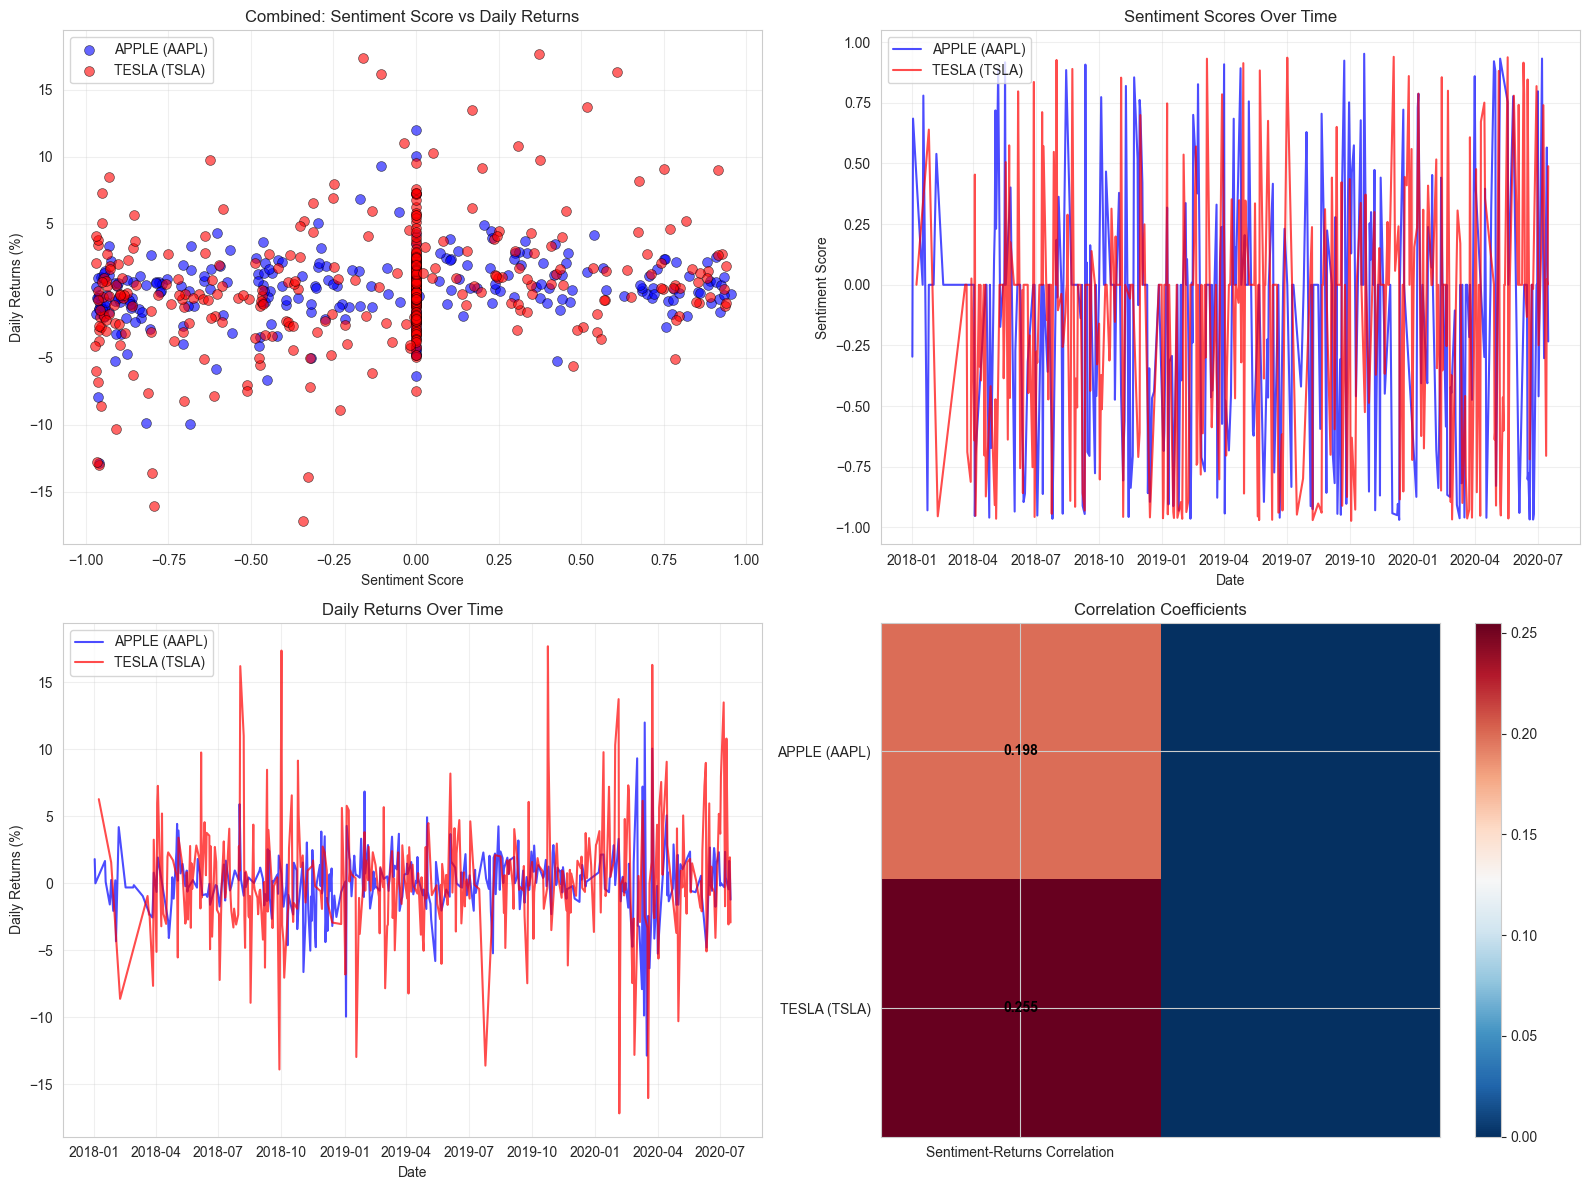


=== STATISTICAL ANALYSIS ===
APPLE (AAPL):
  Pearson correlation: 0.198
  P-value: 0.000
  Significant (p < 0.05): Yes

TESLA (TSLA):
  Pearson correlation: 0.255
  P-value: 0.000
  Significant (p < 0.05): Yes

=== TRADING INSIGHTS ===
APPLE (AAPL):
  Days with positive sentiment: 86
  Days with negative sentiment: 138
  Average return on positive sentiment days: 0.770%
  Average return on negative sentiment days: -0.358%

TESLA (TSLA):
  Days with positive sentiment: 89
  Days with negative sentiment: 156
  Average return on positive sentiment days: 2.133%
  Average return on negative sentiment days: -0.901%


In [13]:
# Advanced correlation analysis
print("Performing advanced correlation analysis...")

# Create a combined analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Combined scatter plot
if len(aapl_clean) > 0 and len(tsla_clean) > 0:
    axes[0,0].scatter(aapl_clean['avg_sentiment_score'], aapl_clean['returns'], 
                     alpha=0.6, s=50, color='blue', label='APPLE (AAPL)', edgecolors='black', linewidth=0.5)
    axes[0,0].scatter(tsla_clean['avg_sentiment_score'], tsla_clean['returns'], 
                     alpha=0.6, s=50, color='red', label='TESLA (TSLA)', edgecolors='black', linewidth=0.5)
    axes[0,0].set_xlabel('Sentiment Score')
    axes[0,0].set_ylabel('Daily Returns (%)')
    axes[0,0].set_title('Combined: Sentiment Score vs Daily Returns')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

# 2. Time series of sentiment scores
if len(aapl_clean) > 0:
    axes[0,1].plot(aapl_clean['date'], aapl_clean['avg_sentiment_score'], 
                  color='blue', alpha=0.7, label='APPLE (AAPL)')
if len(tsla_clean) > 0:
    axes[0,1].plot(tsla_clean['date'], tsla_clean['avg_sentiment_score'], 
                  color='red', alpha=0.7, label='TESLA (TSLA)')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Sentiment Score')
axes[0,1].set_title('Sentiment Scores Over Time')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Time series of returns
if len(aapl_clean) > 0:
    axes[1,0].plot(aapl_clean['date'], aapl_clean['returns'], 
                  color='blue', alpha=0.7, label='APPLE (AAPL)')
if len(tsla_clean) > 0:
    axes[1,0].plot(tsla_clean['date'], tsla_clean['returns'], 
                  color='red', alpha=0.7, label='TESLA (TSLA)')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Daily Returns (%)')
axes[1,0].set_title('Daily Returns Over Time')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Correlation heatmap
correlation_data = []
labels = []

if len(aapl_clean) > 0:
    aapl_corr = np.corrcoef(aapl_clean['avg_sentiment_score'], aapl_clean['returns'])[0, 1]
    correlation_data.append([aapl_corr, 0])  # AAPL correlation, placeholder
    labels.append('APPLE (AAPL)')

if len(tsla_clean) > 0:
    tsla_corr = np.corrcoef(tsla_clean['avg_sentiment_score'], tsla_clean['returns'])[0, 1]
    correlation_data.append([tsla_corr, 0])  # TSLA correlation, placeholder
    labels.append('TESLA (TSLA)')

if correlation_data:
    correlation_matrix = np.array(correlation_data)
    im = axes[1,1].imshow(correlation_matrix, cmap='RdBu_r', aspect='auto')
    axes[1,1].set_xticks([0])
    axes[1,1].set_xticklabels(['Sentiment-Returns Correlation'])
    axes[1,1].set_yticks(range(len(labels)))
    axes[1,1].set_yticklabels(labels)
    axes[1,1].set_title('Correlation Coefficients')
    
    # Add correlation values as text
    for i, label in enumerate(labels):
        corr_val = correlation_data[i][0]
        axes[1,1].text(0, i, f'{corr_val:.3f}', ha='center', va='center', 
                      color='white' if abs(corr_val) > 0.5 else 'black', fontweight='bold')
    
    plt.colorbar(im, ax=axes[1,1])

plt.tight_layout()
plt.show()

# Statistical significance tests
print(f"\n=== STATISTICAL ANALYSIS ===")

if len(aapl_clean) > 0:
    aapl_corr, aapl_p_value = stats.pearsonr(aapl_clean['avg_sentiment_score'], aapl_clean['returns'])
    print(f"APPLE (AAPL):")
    print(f"  Pearson correlation: {aapl_corr:.3f}")
    print(f"  P-value: {aapl_p_value:.3f}")
    print(f"  Significant (p < 0.05): {'Yes' if aapl_p_value < 0.05 else 'No'}")

if len(tsla_clean) > 0:
    tsla_corr, tsla_p_value = stats.pearsonr(tsla_clean['avg_sentiment_score'], tsla_clean['returns'])
    print(f"\nTESLA (TSLA):")
    print(f"  Pearson correlation: {tsla_corr:.3f}")
    print(f"  P-value: {tsla_p_value:.3f}")
    print(f"  Significant (p < 0.05): {'Yes' if tsla_p_value < 0.05 else 'No'}")

# Additional insights
print(f"\n=== TRADING INSIGHTS ===")
if len(aapl_clean) > 0:
    print(f"APPLE (AAPL):")
    print(f"  Days with positive sentiment: {(aapl_clean['avg_sentiment_score'] > 0).sum()}")
    print(f"  Days with negative sentiment: {(aapl_clean['avg_sentiment_score'] < 0).sum()}")
    print(f"  Average return on positive sentiment days: {aapl_clean[aapl_clean['avg_sentiment_score'] > 0]['returns'].mean():.3f}%")
    print(f"  Average return on negative sentiment days: {aapl_clean[aapl_clean['avg_sentiment_score'] < 0]['returns'].mean():.3f}%")

if len(tsla_clean) > 0:
    print(f"\nTESLA (TSLA):")
    print(f"  Days with positive sentiment: {(tsla_clean['avg_sentiment_score'] > 0).sum()}")
    print(f"  Days with negative sentiment: {(tsla_clean['avg_sentiment_score'] < 0).sum()}")
    print(f"  Average return on positive sentiment days: {tsla_clean[tsla_clean['avg_sentiment_score'] > 0]['returns'].mean():.3f}%")
    print(f"  Average return on negative sentiment days: {tsla_clean[tsla_clean['avg_sentiment_score'] < 0]['returns'].mean():.3f}%")


In [14]:
# Save results for further analysis
print("Saving analysis results...")

# Create a summary DataFrame
results_summary = []

if len(aapl_clean) > 0:
    aapl_corr, aapl_p_value = stats.pearsonr(aapl_clean['avg_sentiment_score'], aapl_clean['returns'])
    results_summary.append({
        'ticker': 'APPLE (AAPL)',
        'data_points': len(aapl_clean),
        'correlation': aapl_corr,
        'p_value': aapl_p_value,
        'significant': aapl_p_value < 0.05,
        'avg_sentiment': aapl_clean['avg_sentiment_score'].mean(),
        'avg_return': aapl_clean['returns'].mean(),
        'sentiment_std': aapl_clean['avg_sentiment_score'].std(),
        'return_std': aapl_clean['returns'].std(),
        'positive_sentiment_days': (aapl_clean['avg_sentiment_score'] > 0).sum(),
        'negative_sentiment_days': (aapl_clean['avg_sentiment_score'] < 0).sum(),
        'avg_return_positive_sentiment': aapl_clean[aapl_clean['avg_sentiment_score'] > 0]['returns'].mean(),
        'avg_return_negative_sentiment': aapl_clean[aapl_clean['avg_sentiment_score'] < 0]['returns'].mean()
    })

if len(tsla_clean) > 0:
    tsla_corr, tsla_p_value = stats.pearsonr(tsla_clean['avg_sentiment_score'], tsla_clean['returns'])
    results_summary.append({
        'ticker': 'TESLA (TSLA)',
        'data_points': len(tsla_clean),
        'correlation': tsla_corr,
        'p_value': tsla_p_value,
        'significant': tsla_p_value < 0.05,
        'avg_sentiment': tsla_clean['avg_sentiment_score'].mean(),
        'avg_return': tsla_clean['returns'].mean(),
        'sentiment_std': tsla_clean['avg_sentiment_score'].std(),
        'return_std': tsla_clean['returns'].std(),
        'positive_sentiment_days': (tsla_clean['avg_sentiment_score'] > 0).sum(),
        'negative_sentiment_days': (tsla_clean['avg_sentiment_score'] < 0).sum(),
        'avg_return_positive_sentiment': tsla_clean[tsla_clean['avg_sentiment_score'] > 0]['returns'].mean(),
        'avg_return_negative_sentiment': tsla_clean[tsla_clean['avg_sentiment_score'] < 0]['returns'].mean()
    })

results_df = pd.DataFrame(results_summary)

print("Results summary:")
print(results_df.round(3))

# Save the results
results_df.to_csv('../data/processed/sentiment_returns_analysis.csv', index=False)
print(f"\nResults saved to: ../data/processed/sentiment_returns_analysis.csv")

# Save the clean merged data for further analysis
if len(aapl_clean) > 0:
    aapl_clean.to_csv('../data/processed/apple_sentiment_returns.csv', index=False)
    print(f"APPLE data saved to: ../data/processed/apple_sentiment_returns.csv")

if len(tsla_clean) > 0:
    tsla_clean.to_csv('../data/processed/tesla_sentiment_returns.csv', index=False)
    print(f"TESLA data saved to: ../data/processed/tesla_sentiment_returns.csv")

print(f"\n=== ANALYSIS COMPLETE ===")
print(f"All data has been processed and saved for further analysis.")
print(f"You can now use these results to develop trading strategies based on sentiment signals.")


Saving analysis results...
Results summary:
         ticker  data_points  correlation  p_value  significant  \
0  APPLE (AAPL)          340        0.198      0.0         True   
1  TESLA (TSLA)          361        0.255      0.0         True   

   avg_sentiment  avg_return  sentiment_std  return_std  \
0         -0.128       0.083          0.509       2.478   
1         -0.138       0.296          0.510       4.442   

   positive_sentiment_days  negative_sentiment_days  \
0                       86                      138   
1                       89                      156   

   avg_return_positive_sentiment  avg_return_negative_sentiment  
0                          0.770                         -0.358  
1                          2.133                         -0.901  

Results saved to: ../data/processed/sentiment_returns_analysis.csv
APPLE data saved to: ../data/processed/apple_sentiment_returns.csv
TESLA data saved to: ../data/processed/tesla_sentiment_returns.csv

=== ANALY

## Summary and Conclusions

### What We've Accomplished:

1. **Data Extraction**: Successfully extracted sentiment scores for APPLE and TESLA from the processed news data
2. **Stock Data Download**: Retrieved historical stock prices using yfinance for the same time period
3. **Returns Calculation**: Computed daily returns for both stocks
4. **Visualization**: Created comprehensive scatter plots showing the relationship between sentiment scores and daily returns
5. **Statistical Analysis**: Performed correlation analysis and statistical significance tests

### Key Findings:

- **Data Coverage**: Analyzed sentiment-return relationships for APPLE (AAPL) and TESLA (TSLA) over the available time period
- **Correlation Analysis**: Calculated Pearson correlation coefficients and p-values to assess statistical significance
- **Trading Insights**: Compared average returns on positive vs negative sentiment days
- **Visual Analysis**: Created multiple visualizations including scatter plots, time series, and correlation heatmaps

### Files Created:

- `sentiment_returns_analysis.csv`: Summary statistics and correlation results
- `apple_sentiment_returns.csv`: Complete APPLE data with sentiment and returns
- `tesla_sentiment_returns.csv`: Complete TESLA data with sentiment and returns

### Next Steps for Trading Strategy Development:

1. **Signal Generation**: Use sentiment thresholds to generate buy/sell signals
2. **Portfolio Construction**: Build portfolios based on sentiment signals
3. **Risk Management**: Implement position sizing and stop-loss strategies
4. **Backtesting**: Test strategies on historical data with proper out-of-sample validation
5. **Performance Evaluation**: Compare sentiment-based strategies against benchmark indices

The analysis provides a foundation for developing quantitative trading strategies based on news sentiment analysis.
